In [31]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, roc_curve, auc,classification_report
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


from tensorflow.keras.models import load_model
import joblib
import json

from config import DATA_PATH, PROCESSED_DATA_PATH, SENTENCES, MODEL_SAVE_PATH

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [32]:
# !pip install scikit-learn tensorflow

/var/folders/nb/6rxqchpx425dyjql5p01n12w0000gn/T/ipykernel_71618/1911787946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=Y_raw, palette="viridis", order=np.unique(Y_raw))


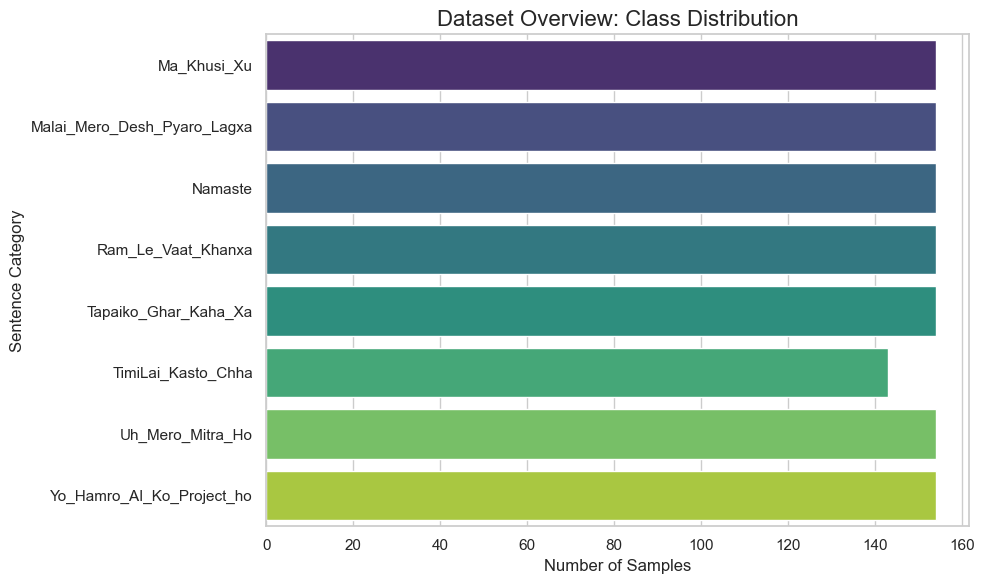

In [33]:
# Load Y.npy to see the class distribution
Y_raw = np.load(os.path.join(PROCESSED_DATA_PATH, 'Y.npy'))

plt.figure(figsize=(10, 6))
sns.countplot(y=Y_raw, palette="viridis", order=np.unique(Y_raw))
plt.title('Dataset Overview: Class Distribution', fontsize=16)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Sentence Category', fontsize=12)
plt.tight_layout()
plt.show()

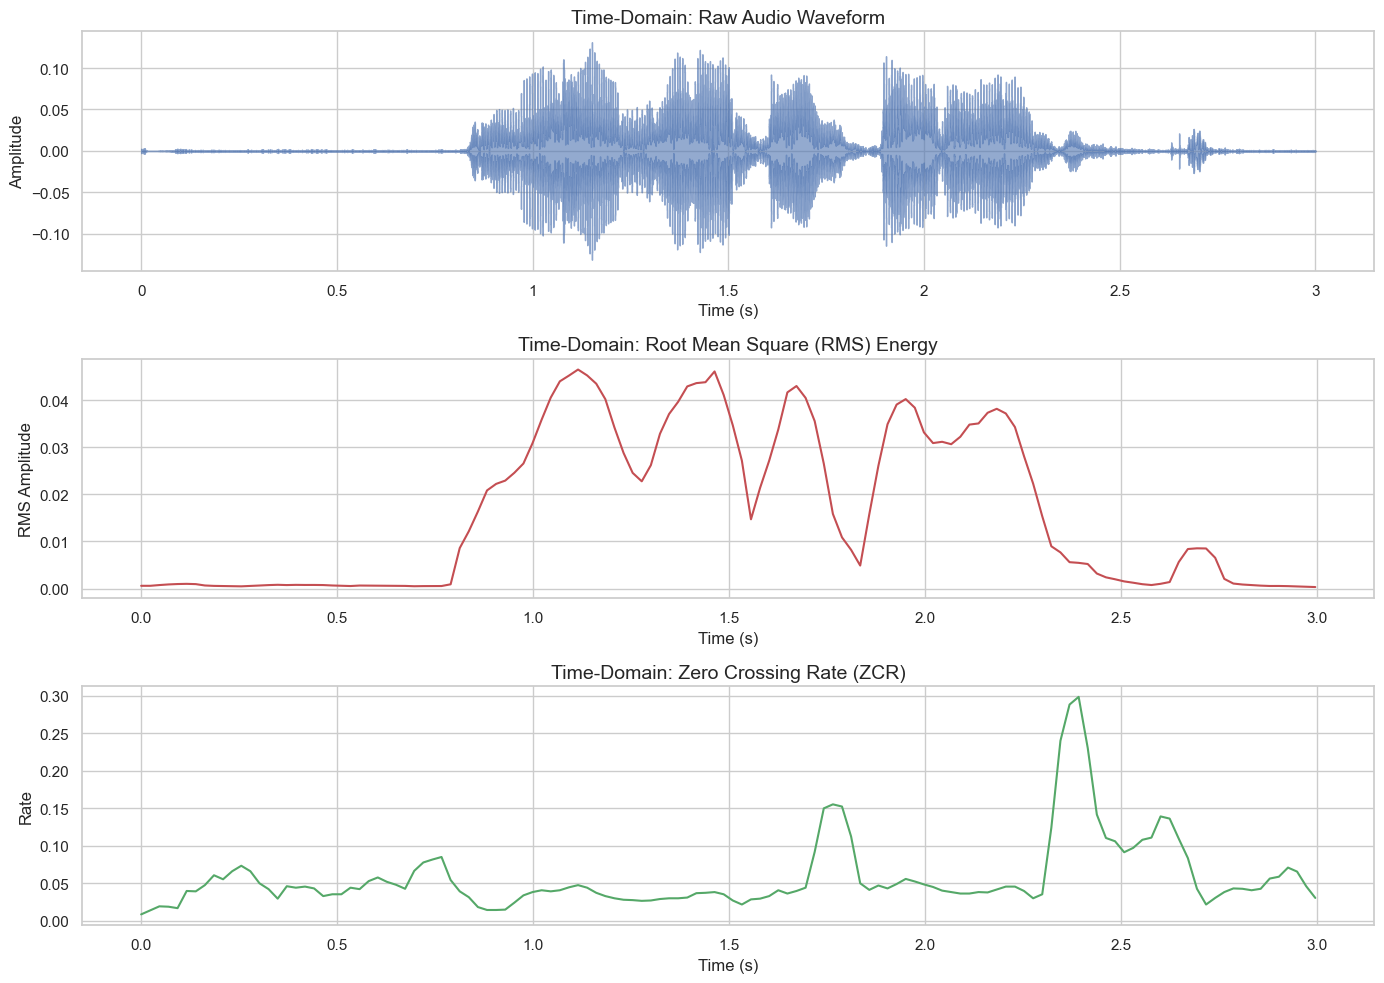

In [34]:
# Load a sample audio file
SAMPLE_AUDIO_PATH="/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/data/raw/Malai_Mero_Desh_Pyaro_Lagxa/sk01_s02.wav"
audio, sr = librosa.load(SAMPLE_AUDIO_PATH, sr=22050)

plt.figure(figsize=(14, 10))

# 1. Raw Audio Waveform
plt.subplot(3, 1, 1)
librosa.display.waveshow(audio, sr=sr, alpha=0.6)
plt.title('Time-Domain: Raw Audio Waveform', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# 2. RMS Energy
rms = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
frames = range(len(rms))
t = librosa.frames_to_time(frames, hop_length=512, sr=sr)
plt.subplot(3, 1, 2)
plt.plot(t, rms, color='r')
plt.title('Time-Domain: Root Mean Square (RMS) Energy', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('RMS Amplitude')

# 3. Zero Crossing Rate (ZCR)
zcr = librosa.feature.zero_crossing_rate(y=audio, frame_length=2048, hop_length=512)[0]
plt.subplot(3, 1, 3)
plt.plot(t, zcr, color='g')
plt.title('Time-Domain: Zero Crossing Rate (ZCR)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Rate')

plt.tight_layout()
plt.show()

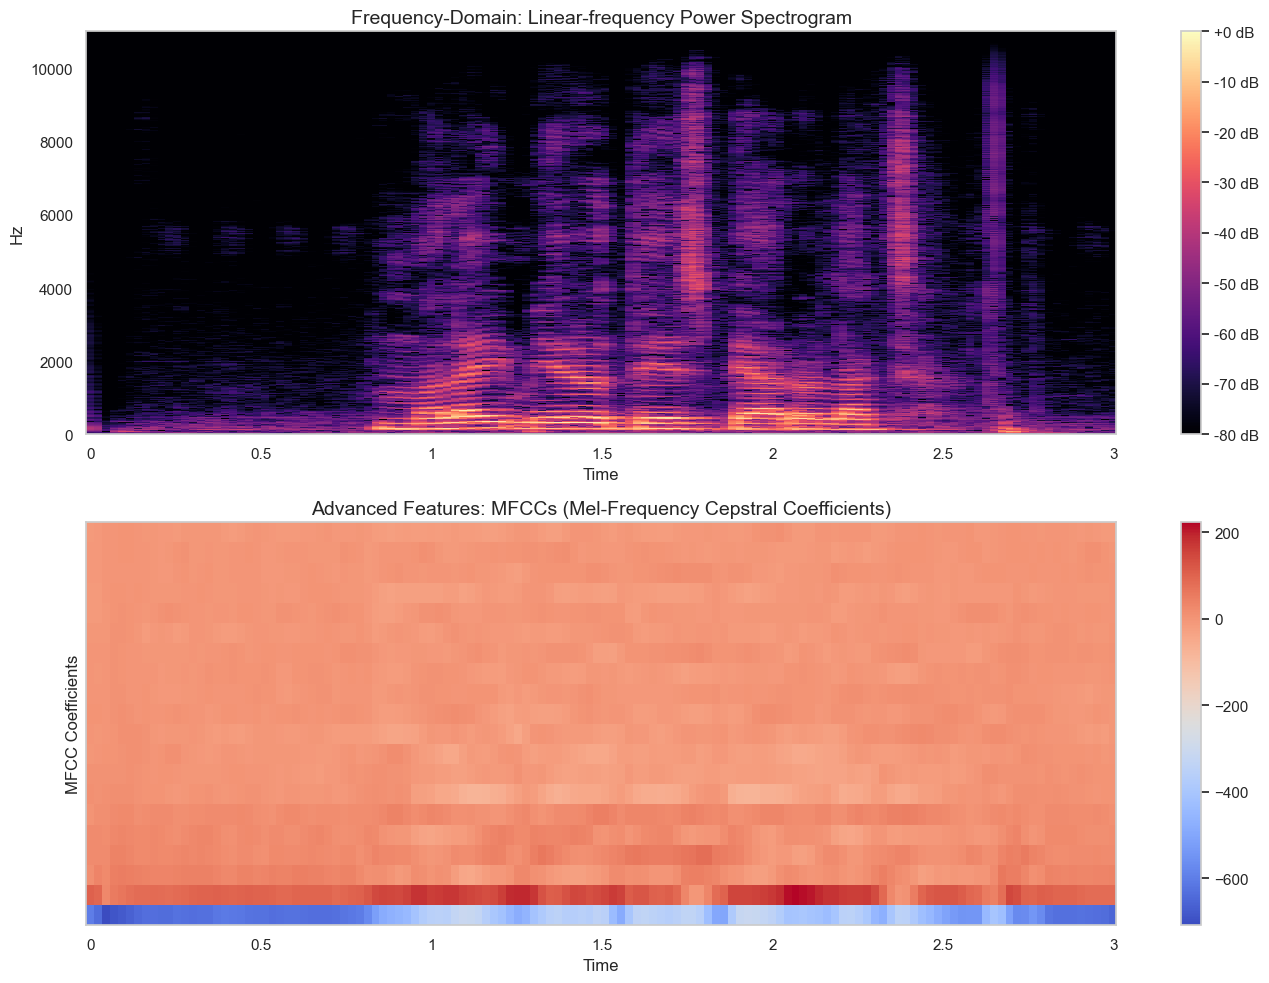

In [35]:
plt.figure(figsize=(14, 10))

# 1. Spectrogram (Frequency Domain)
# Convert to decibels for better visualization
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
plt.subplot(2, 1, 1)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Frequency-Domain: Linear-frequency Power Spectrogram', fontsize=14)

# 2. Mel-Frequency Cepstral Coefficients (MFCCs - Advanced Features)
# Note: Using n_mfcc=20 to match your data_prep.py default
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)
plt.subplot(2, 1, 2)
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('Advanced Features: MFCCs (Mel-Frequency Cepstral Coefficients)', fontsize=14)
plt.ylabel('MFCC Coefficients')

plt.tight_layout()
plt.show()

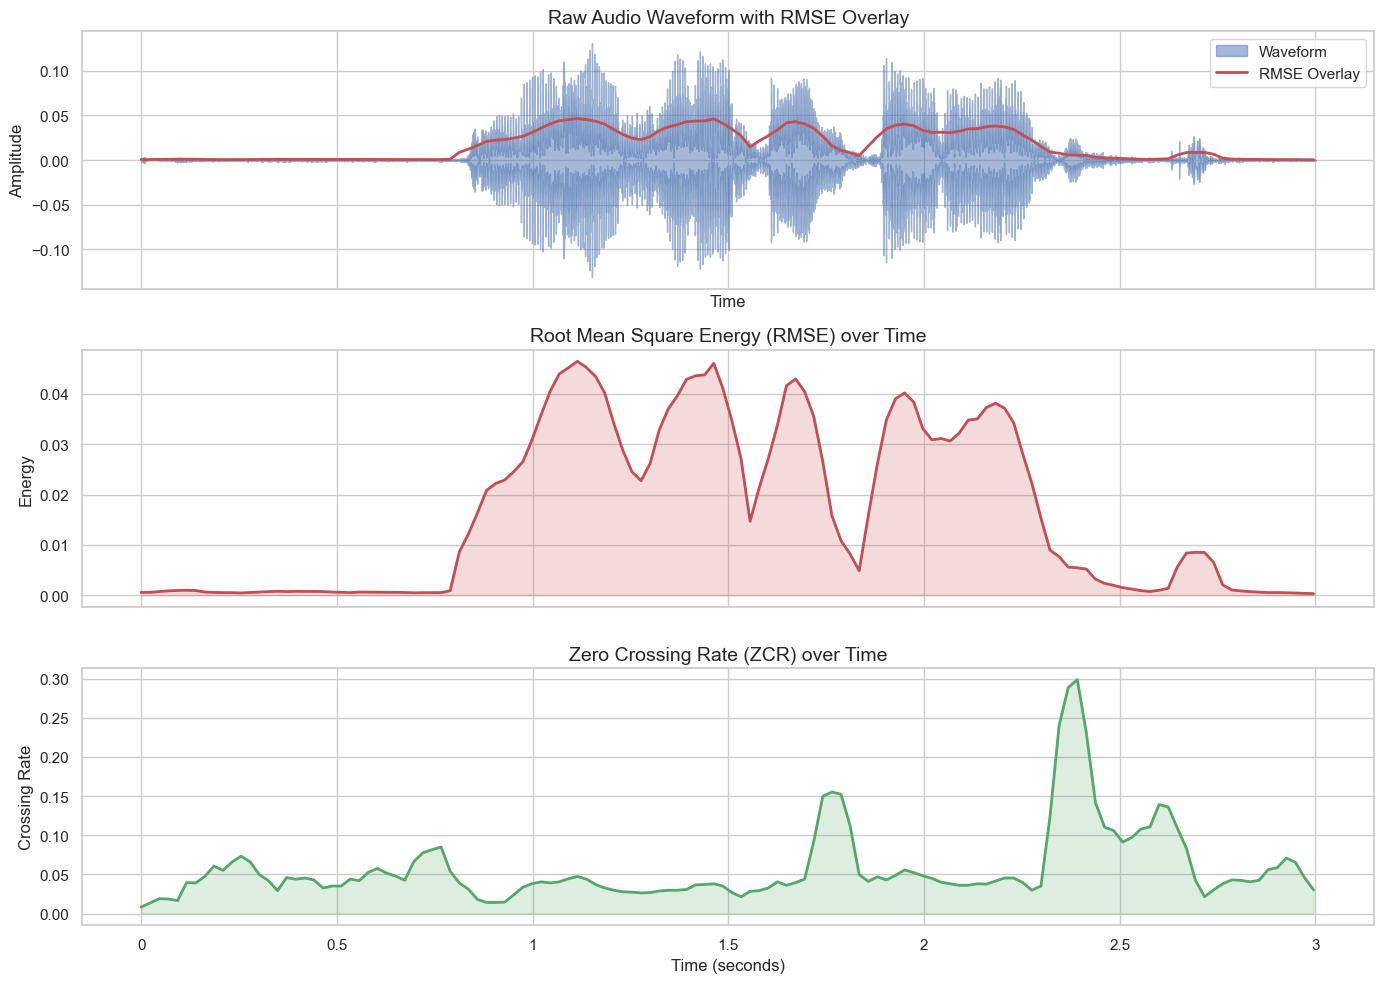

In [36]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters from your data_prep.py ---
FRAME_LENGTH = 2048
HOP_LENGTH = 512

# 1. Load the audio file
SAMPLE_AUDIO_PATH="/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/data/raw/Malai_Mero_Desh_Pyaro_Lagxa/sk01_s02.wav"

audio, sr = librosa.load(SAMPLE_AUDIO_PATH, sr=22050)

# 2. Extract Features (RMSE and ZCR)
# Using [0] to squeeze the array from 2D to 1D for plotting
rmse_val = librosa.feature.rms(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
zcr_val = librosa.feature.zero_crossing_rate(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

# 3. Create a time array for the features so they align perfectly with the audio length
frames = range(len(rmse_val))
time_axis = librosa.frames_to_time(frames, hop_length=HOP_LENGTH, sr=sr)

# --- Plotting ---
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot A: Raw Waveform with RMSE overlay
librosa.display.waveshow(audio, sr=sr, ax=ax[0], alpha=0.5, label='Waveform')
ax[0].plot(time_axis, rmse_val, color='r', label='RMSE Overlay', lw=2)
ax[0].set_title('Raw Audio Waveform with RMSE Overlay', fontsize=14)
ax[0].set_ylabel('Amplitude')
ax[0].legend(loc='upper right')

# Plot B: RMSE (Standalone)
ax[1].plot(time_axis, rmse_val, color='r', lw=2)
ax[1].set_title('Root Mean Square Energy (RMSE) over Time', fontsize=14)
ax[1].set_ylabel('Energy')
ax[1].fill_between(time_axis, rmse_val, color='r', alpha=0.2) # Fills the area under the curve

# Plot C: ZCR (Standalone)
ax[2].plot(time_axis, zcr_val, color='g', lw=2)
ax[2].set_title('Zero Crossing Rate (ZCR) over Time', fontsize=14)
ax[2].set_xlabel('Time (seconds)', fontsize=12)
ax[2].set_ylabel('Crossing Rate')
ax[2].fill_between(time_axis, zcr_val, color='g', alpha=0.2)

plt.tight_layout()
plt.show()

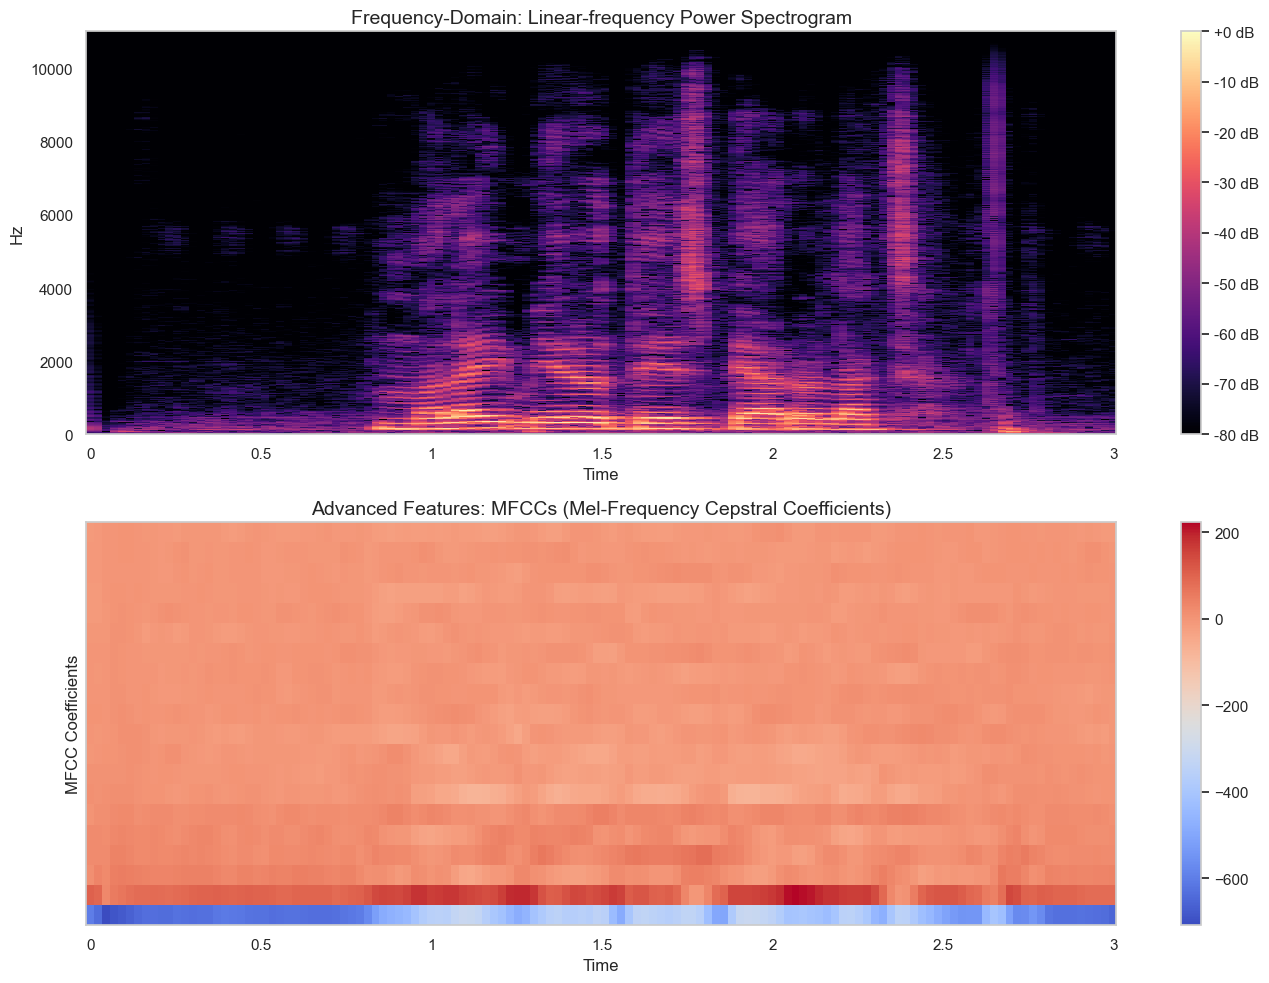

In [37]:
plt.figure(figsize=(14, 10))

# 1. Spectrogram (Frequency Domain)
# Convert to decibels for better visualization
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
plt.subplot(2, 1, 1)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Frequency-Domain: Linear-frequency Power Spectrogram', fontsize=14)

# 2. Mel-Frequency Cepstral Coefficients (MFCCs - Advanced Features)
# Note: Using n_mfcc=20 to match your data_prep.py default
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)
plt.subplot(2, 1, 2)
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('Advanced Features: MFCCs (Mel-Frequency Cepstral Coefficients)', fontsize=14)
plt.ylabel('MFCC Coefficients')

plt.tight_layout()
plt.show()

NameError: name 'y' is not defined

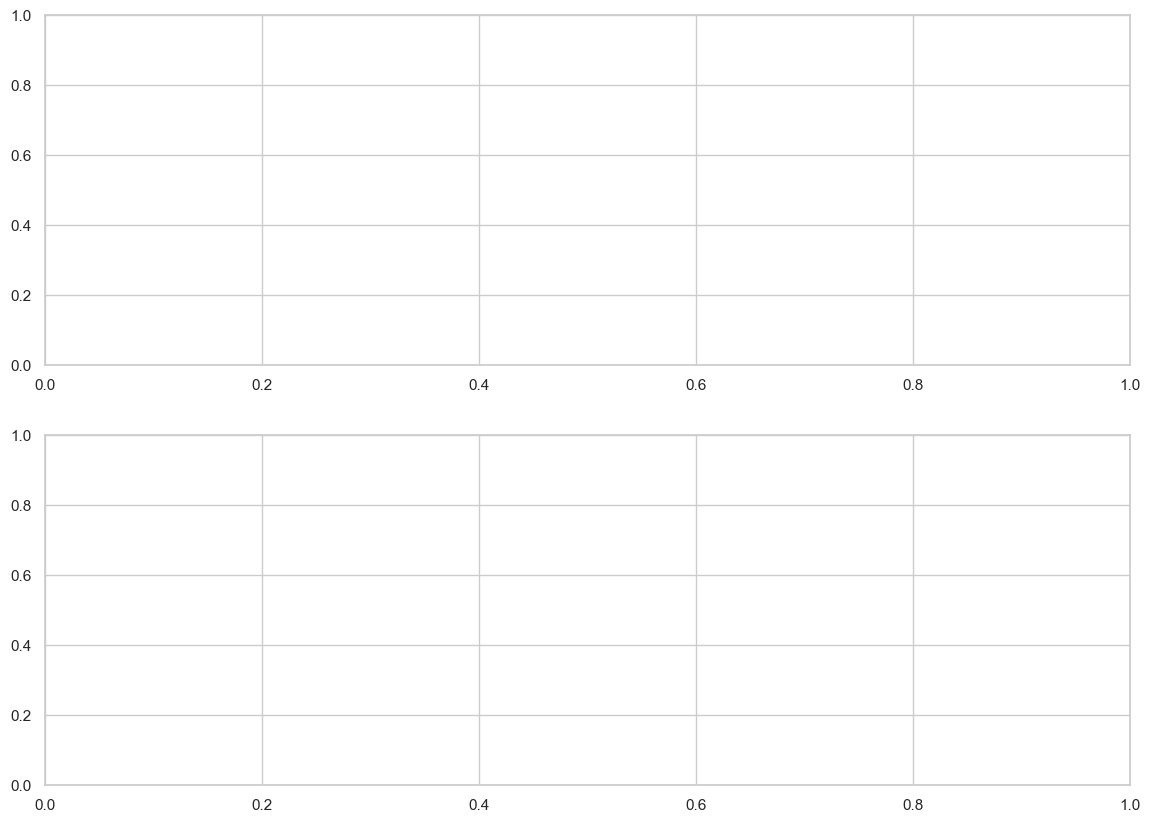

In [38]:
# Cell 5: Spectrogram & Mel-Spectrogram
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# 1. Standard Spectrogram (STFT)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img1 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax[0])
fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")
ax[0].set_title('Log-frequency Power Spectrogram')

# 2. Mel-Spectrogram
M = librosa.feature.melspectrogram(y=y, sr=sr)
M_db = librosa.power_to_db(M, ref=np.max)
img2 = librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='mel', ax=ax[1])
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")
ax[1].set_title('Mel-Spectrogram')

plt.tight_layout()
plt.show()

In [44]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# --- UPDATED PATHS ---
TEST_PROCESSED_DATA_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/test/processed"
MODEL_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/nepali_lstm_model.h5"
SCALER_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/scaler.joblib"
ENCODER_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/label_encoder.joblib"

def plot_confusion_matrix():
    print("Loading test data and model components...")
    try:
        X_test = np.load(os.path.join(TEST_PROCESSED_DATA_PATH, 'X.npy'))
        Y_true = np.load(os.path.join(TEST_PROCESSED_DATA_PATH, 'Y.npy')) # Ground-truth strings
    except FileNotFoundError:
        print("❌ Error: Could not find X.npy or Y.npy. Ensure your test data is processed.")
        return

    model = load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    label_encoder = joblib.load(ENCODER_PATH)

    print("\n--- Diagnostic Info ---")
    print(f"X_test original shape: {X_test.shape}")
    print(f"Model expects input shape: {model.input_shape}")
    print(f"Scaler expects features: {scaler.n_features_in_}")
    print("-----------------------\n")

    print("Scaling features...")
    
    # SCENARIO A: 3D LSTM Data (e.g., samples, time_steps, 15 features)
    if len(X_test.shape) == 3 and X_test.shape[-1] == scaler.n_features_in_:
        samples, time_steps, features = X_test.shape
        # Reshape to 2D to scale the features across all time steps safely
        X_test_2d = X_test.reshape(-1, features)
        X_test_scaled_2d = scaler.transform(X_test_2d)
        # Reshape back to 3D for the LSTM
        X_test_scaled = X_test_scaled_2d.reshape(samples, time_steps, features)

    # SCENARIO B: The Scaler is the wrong file
    elif scaler.n_features_in_ == 15 and (X_test.shape[1] == 4004 or X_test.shape[1] * X_test.shape[2] == 4004):
        raise ValueError("🚨 SCALER MISMATCH: Your data has 4004 features, but this scaler expects 15. You have loaded the wrong scaler.joblib file for this specific model.")

    # SCENARIO C: Standard 2D Flattening
    else:
        if len(X_test.shape) == 3:
            X_test_2d = X_test.reshape(X_test.shape[0], -1)
        else:
            X_test_2d = X_test
        X_test_scaled = scaler.transform(X_test_2d)
    
    print("Generating predictions...")
    # Predict and decode
    prediction_probs = model.predict(X_test_scaled)
    predicted_indices = np.argmax(prediction_probs, axis=1)
    predicted_sentences = label_encoder.inverse_transform(predicted_indices)

    print("Generating confusion matrix plotting...")
    # Grab the unique classes directly from your encoder
    class_labels = label_encoder.classes_
    
    # Calculate the matrix
    cm = confusion_matrix(Y_true, predicted_sentences, labels=class_labels)

    # --- Plotting Logic ---
    plt.figure(figsize=(12, 10)) 
    
    # Create a heatmap using seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.title('Nepali Speech Recognition - Confusion Matrix', fontsize=16)
    plt.ylabel('Actual Sentence', fontsize=12)
    plt.xlabel('Predicted Sentence', fontsize=12)
    
    # Rotate the x-axis labels so they don't overlap
    plt.xticks(rotation=45, ha='right') 
    plt.tight_layout()
    
    # Save the plot to your processed folder
    save_path = os.path.join(TEST_PROCESSED_DATA_PATH, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300)
    print(f"✅ Confusion matrix successfully saved to: {save_path}")
    
    # Display the plotimport os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# --- ARTIFACT & DATA PATHS ---
TEST_PROCESSED_DATA_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/test/processed"
MODEL_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/nepali_lstm_model.h5"
SCALER_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/scaler.joblib"
ENCODER_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/label_encoder.joblib"

def plot_confusion_matrix():
    # 1. Load the Test Data
    print("Loading test data and model components...")
    try:
        X_test = np.load(os.path.join(TEST_PROCESSED_DATA_PATH, 'X.npy'))
        Y_true = np.load(os.path.join(TEST_PROCESSED_DATA_PATH, 'Y.npy')) 
    except FileNotFoundError:
        print("❌ Error: Could not find X.npy or Y.npy. Ensure your test data is processed.")
        return

    # 2. Load the Model Artifacts
    model = load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    label_encoder = joblib.load(ENCODER_PATH)

    # 3. Diagnostic Shape Check
    print("\n" + "="*50)
    print("DIAGNOSTIC CHECK")
    print("="*50)
    print(f"1. Test Data Shape (X_test):   {X_test.shape}")
    print(f"2. Model Expected Input Shape: {model.input_shape}")
    print(f"3. Scaler Expected Features:   {scaler.n_features_in_}")
    print("="*50 + "\n")

    # Determine how many features your test data actually has
    if len(X_test.shape) == 3:
        total_data_features = X_test.shape[1] * X_test.shape[2]
    else:
        total_data_features = X_test.shape[1]

    # 4. Safe Scaling / Error Handling
    if scaler.n_features_in_ != total_data_features and scaler.n_features_in_ != X_test.shape[-1]:
        print("🚨 FATAL ERROR: SHAPE MISMATCH DETECTED 🚨")
        print(f"Your processed audio data has {total_data_features} features.")
        print(f"But your scaler.joblib expects exactly {scaler.n_features_in_} features.")
        print("\n--- HOW TO FIX THIS ---")
        print("▶ If your MODEL EXPECTS 4004 features: Your old scaler is outdated. You need to re-run your training script to train a new model/scaler on the 4004-feature data.")
        print("▶ If your MODEL EXPECTS 15 features: Your data_prep.py is wrong. You recently changed it to output 4004 features instead of 15. Revert data_prep.py to extract only 15 features (e.g., taking the mean of MFCCs), and re-run the process_and_save() script.")
        return # Stop execution safely

    print("✅ Shapes align! Scaling features...")
    
    # 5. Smart Reshaping for Scaler
    if len(X_test.shape) == 3 and X_test.shape[-1] == scaler.n_features_in_:
        # Handle 3D LSTM Data properly
        samples, time_steps, features = X_test.shape
        X_test_2d = X_test.reshape(-1, features)
        X_test_scaled_2d = scaler.transform(X_test_2d)
        X_test_scaled = X_test_scaled_2d.reshape(samples, time_steps, features)
    else:
        # Handle Standard Flattened Data
        if len(X_test.shape) == 3:
            X_test_2d = X_test.reshape(X_test.shape[0], -1)
        else:
            X_test_2d = X_test
        X_test_scaled = scaler.transform(X_test_2d)
    
    # 6. Generate Predictions
    print("Generating predictions...")
    prediction_probs = model.predict(X_test_scaled)
    predicted_indices = np.argmax(prediction_probs, axis=1)
    predicted_sentences = label_encoder.inverse_transform(predicted_indices)

    # 7. Generate Confusion Matrix
    print("Generating confusion matrix plotting...")
    class_labels = label_encoder.classes_
    cm = confusion_matrix(Y_true, predicted_sentences, labels=class_labels)

    # 8. Plotting Logic
    plt.figure(figsize=(12, 10)) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.title('Nepali Speech Recognition - Confusion Matrix', fontsize=16)
    plt.ylabel('Actual Sentence', fontsize=12)
    plt.xlabel('Predicted Sentence', fontsize=12)
    
    plt.xticks(rotation=45, ha='right') 
    plt.tight_layout()
    
    # Save Output
    save_path = os.path.join(TEST_PROCESSED_DATA_PATH, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300)
    print(f"✅ Confusion matrix successfully saved to: {save_path}")
    
    # Display Plot
    plt.show()

if __name__ == "__main__":
    plot_confusion_matrix()
    plt.show()

if __name__ == "__main__":
    plot_confusion_matrix()

Loading test data and model components...



DIAGNOSTIC CHECK
1. Test Data Shape (X_test):   (40, 4004, 1)
2. Model Expected Input Shape: (None, 182, 15)
3. Scaler Expected Features:   15

🚨 FATAL ERROR: SHAPE MISMATCH DETECTED 🚨
Your processed audio data has 4004 features.
But your scaler.joblib expects exactly 15 features.

--- HOW TO FIX THIS ---
▶ If your MODEL EXPECTS 4004 features: Your old scaler is outdated. You need to re-run your training script to train a new model/scaler on the 4004-feature data.
▶ If your MODEL EXPECTS 15 features: Your data_prep.py is wrong. You recently changed it to output 4004 features instead of 15. Revert data_prep.py to extract only 15 features (e.g., taking the mean of MFCCs), and re-run the process_and_save() script.
Loading test data and model components...

DIAGNOSTIC CHECK
1. Test Data Shape (X_test):   (40, 4004, 1)
2. Model Expected Input Shape: (None, 182, 15)
3. Scaler Expected Features:   15

🚨 FATAL ERROR: SHAPE MISMATCH DETECTED 🚨
Your processed audio data has 4004 features.
But y